
<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 3: Clasificación con una Red Neuronal Profunda con TensorFlow y Pytorch</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Construir, entrenar y evaluar un MLP profundo en TensorFlow y Pytorch sobre un conjunto de datos real, aplicando las técnicas vistas (regularización, optimizadores, curvas de aprendizaje).
</div>


### Instrucciones

Trabajaremos con el dataset de imágenes **CIFAR-10**: 60 000 imágenes a color de $32\times32$ píxeles (50 000 de entrenamiento y 10 000 de prueba) repartidas en **10 clases** (avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco, camión). Está disponible de forma nativa tanto en TensorFlow (`keras.datasets.cifar10`) como en PyTorch (`torchvision.datasets.CIFAR10`).

1. **Carga y explora** el dataset: normaliza los píxeles a $[0, 1]$, **aplana** cada imagen a un vector de $32\times32\times3 = 3072$ valores (para el MLP) y **visualiza** algunos ejemplos con su clase.
2. Divide en train/validación y usa el conjunto de prueba oficial.
3. Construye un **MLP profundo con Tensorflow** (**Modelo 1**): al menos 3 capas ocultas, con `BatchNormalization`, `Dropout` y optimizador **Adam**. Define la entrada con `keras.Input(shape=(3072,))`. Entrena y reporta la precisión en test.
4. Construye el **mismo MLP con PyTorch** (**Modelo 2**): entrena con **AdamW** y un **scheduler** de tu elección (p. ej. `StepLR` o `CosineAnnealingLR`).
5. Grafica las **curvas de aprendizaje** (pérdida y precisión) de ambos modelos y reporta la **precisión en test**.
6. Muestra la **matriz de confusión** e identifica qué clases se confunden más.
7. **Compara** ambas implementaciones y anota tus conclusiones.

> un MLP sobre imágenes a color suele alcanzar ~45–55 % de precisión en CIFAR-10. Es un buen punto de partida para motivar el uso de **redes convolucionales (CNN)** más adelante.


### 0. Carga y exploración del dataset (CIFAR-10)

Esta parte ya está resuelta: carga el dataset, lo normaliza, lo aplana y muestra algunos ejemplos. Reutilizarás estas variables (`X_train`, `y_train`, `X_test`, `y_test`) en ambos modelos.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1593s 9us/step
Entrenamiento: (50000, 3072) | Prueba: (10000, 3072)
Clases: [0 1 2 3 4 5 6 7 8 9]


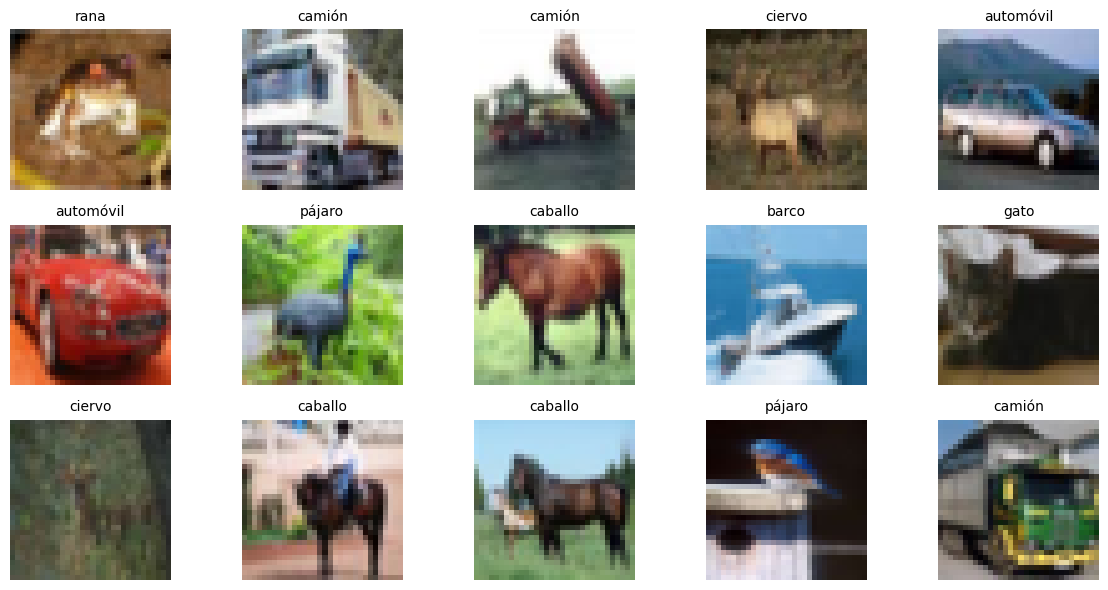

In [1]:
import os

# Evita el conflicto de múltiples runtimes OpenMP (MKL + libgomp) en Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# Nombres de las 10 clases de CIFAR-10
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Cargar el dataset (imágenes 32x32x3, etiquetas 0-9)
(X_train_img, y_train), (X_test_img, y_test) = cifar10.load_data()
y_train, y_test = y_train.ravel(), y_test.ravel()   # de (N,1) a (N,)

# Normalizar a [0,1] y aplanar a vectores de 3072 (para el MLP)
X_train = (X_train_img / 255.0).reshape(-1, 32 * 32 * 3).astype('float32')
X_test  = (X_test_img  / 255.0).reshape(-1, 32 * 32 * 3).astype('float32')

print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)
print('Clases:', np.unique(y_train))

# Visualizar 15 imágenes con su clase
plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train_img[i])          # imagen original a color
    plt.title(class_names[y_train[i]], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

### 1. Modelo con TensorFlow

In [ ]:
import tensorflow as tf

# TODO 1: construye un MLP profundo con la API Sequential
#   - keras.Input(shape=(3072,))
#   - >= 3 capas Dense ocultas (p. ej. 512, 256, 128) con activación 'relu'
#   - usa BatchNormalization y Dropout entre capas
#   - capa de salida Dense(10, activation='softmax')
model_tf = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(3072,)),
    # ... completa aquí ...
])

# TODO 2: compila con optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']

# TODO 3: entrena guardando el history (usa validation_split=0.1 y varias épocas)
# history_tf = model_tf.fit(X_train, y_train, ...)

# TODO 4: evalúa en test e imprime la precisión
# test_loss, test_acc = model_tf.evaluate(X_test, y_test)

### 2. Modelo con Pytorch

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reutilizamos los MISMOS datos de CIFAR-10 ya normalizados y aplanados (3072)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# TODO 1: separa un 10% del entrenamiento para validación
# TODO 2: crea TensorDataset y DataLoader (train/val/test) con batch_size=128
print('Tensores listos:', X_train_t.shape, X_test_t.shape, '| Dispositivo:', device)

In [ ]:
# TODO 3: define tu MLP profundo (>= 3 capas ocultas, BatchNorm, Dropout)
#   Entrada: 3072 features -> salida: 10 clases (logits, sin softmax)
class MiMLP(nn.Module):
    def __init__(self, num_features=3072, num_classes=10):
        super().__init__()
        # ... completa aquí (nn.Linear, nn.BatchNorm1d, nn.ReLU, nn.Dropout) ...
        pass

    def forward(self, x):
        # ... completa aquí ...
        pass

In [ ]:
# TODO 4: bucle de entrenamiento con AdamW + scheduler
# TODO 5: curvas de aprendizaje y precisión en test

In [ ]:
# TODO 6: matriz de confusión
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay